In [1]:
%load_ext autoreload
%autoreload 2

# Unproject LUT (LookUp Table) example

Going from a pixel location to a 3D camera-frame ray (`unproject` / `normalize_points`) usually has no closed form and has to be solved iteratively, which can be too slow for some applications.

Lensboy lets you precompute these values once on a regular pixel grid and interpolate at runtime, trading a one-time build for fast queries afterwards.

This notebook builds a LUT from a bundled test calibration, saves it as a directory under `examples/generated/`, reloads it, and uses `compute_lut_error_heatmap` to compare the cached rays against the exact camera model.

In [ ]:
from pathlib import Path

import lensboy as lb
from lensboy.analysis import compute_lut_error_heatmap, UnprojectLUTErrorHeatmap

In [3]:
repo_root = Path(".").resolve().parent
data_dir = repo_root / "data" / "test_datasets"
output_dir = repo_root / "examples" / "generated"
output_dir.mkdir(parents=True, exist_ok=True)

## Source camera model

A bundled PinholeSplined calibration is used by default. An OpenCV calibration is also available - uncomment the second line in the cell below to switch.

In [4]:
model = lb.PinholeSplined.load(data_dir / "spline.json")
# model = lb.OpenCV.load(data_dir / "opencv.json")
model

PinholeSplined(3088x2064, f=[1355.8, 1355.7], c=[1513.5, 1078.6], knots=30x20, fov=[143.5°, 127.6°])

## Compute the lookup table

Edit the variables below to control how the LUT is created and used.

In [5]:
pixel_stride = 32.0

In [6]:
lut = model.get_unproject_lut(
    pixel_stride=pixel_stride,
)

## Save the lookup-table to disk

In [7]:
lut_filename = (
    f"spline_stride_{int(pixel_stride) if pixel_stride is not None else 'full'}.lut"
)
lut_dir = output_dir / lut_filename
lut.save(lut_dir)
print(f"Saved to {lut_dir.relative_to(repo_root)}")

Saved to examples/generated/spline_stride_32.lut


## Load the lookup-table from disk

In [8]:
loaded = lb.UnprojectLUT.load(lut_dir)

print(f"Grid size: {loaded.grid_width} x {loaded.grid_height}")

Grid size: 98 x 66


In [22]:
interpolation_mode = "bicubic"  # "nearest", "bilinear", or "bicubic"

## Error heatmap

Per-cell maximum angular error for the chosen interpolation mode in milli degrees.

The cyan arrows show the direction of the local peak x/y interpolation error within each sampled cell.

Computed heatmap in 0.01 seconds
Saved heatmap in 0.02 seconds
Loaded heatmap in 0.00 seconds


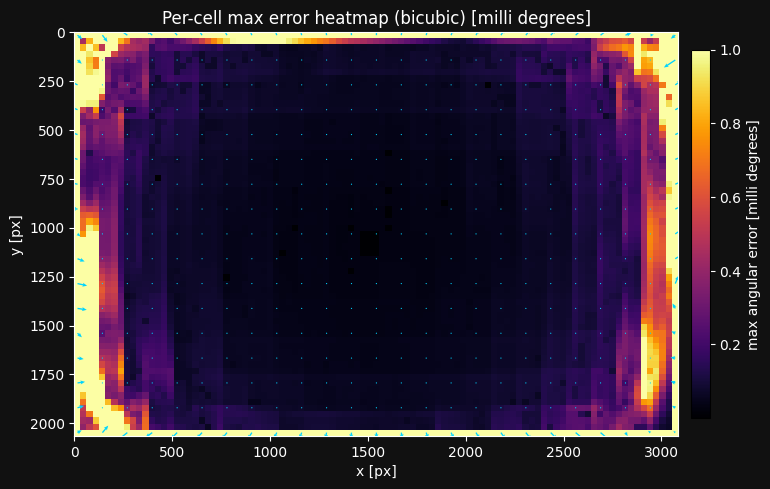

Loaded and plotted heatmap in 0.09 seconds


In [26]:
from timeit import default_timer
heatmap_filename = (
    f"spline_stride_{int(pixel_stride)}"
    f"_{interpolation_mode}_error_heatmap.npz"
)
heatmap_path = output_dir / heatmap_filename

start_time = default_timer()
heatmap = compute_lut_error_heatmap(
    loaded, model, interpolation=interpolation_mode,
)
end_time = default_timer()
print(f"Computed heatmap in {end_time - start_time:.2f} seconds")

start_time = default_timer()
heatmap.save(heatmap_path)
end_time = default_timer()
print(f"Saved heatmap in {end_time - start_time:.2f} seconds")


start_time = default_timer()
loaded_heatmap = UnprojectLUTErrorHeatmap.load(heatmap_path)
end_time = default_timer()
print(f"Loaded heatmap in {end_time - start_time:.2f} seconds")

start_time = default_timer()
heatmap.plot(
    angular_unit="mdeg",
    figsize=(7.8, 5.3),
    arrow_scale=1.0,
    vmax=1.0,

)
end_time = default_timer()
print(f"Loaded and plotted heatmap in {end_time - start_time:.2f} seconds")

## C++ runtime

The same LUT directory can be loaded from the standalone runtime in `cpp_runtime/`. Copy the contents of that directory into your project and use it like so:

```cpp
#include "unproject_lut.hpp"

auto lut = lensboy::UnprojectLUT::load("camera_lut/");
auto result = lut.query(1280.0, 720.0);  // bicubic, unit-length ray

if (result.valid) {
    do_stuff(result.ray);
}
```

See [docs/unproject_lut.md](../docs/unproject_lut.md) for the full C++ API (interpolation modes, ray-convention switch, file format).